## Computer Vision

Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and $k$NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

In [3]:
#1 -- Run the code to load data
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 19

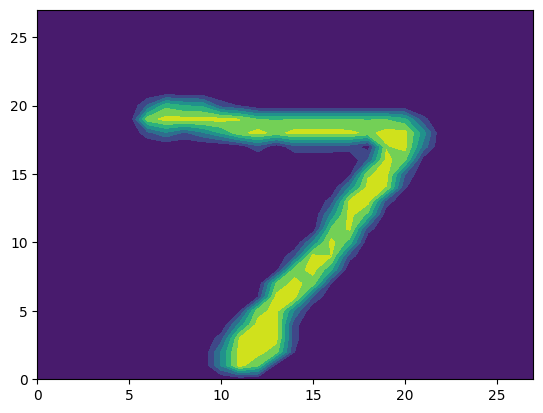

2 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0 209 253 253  65   

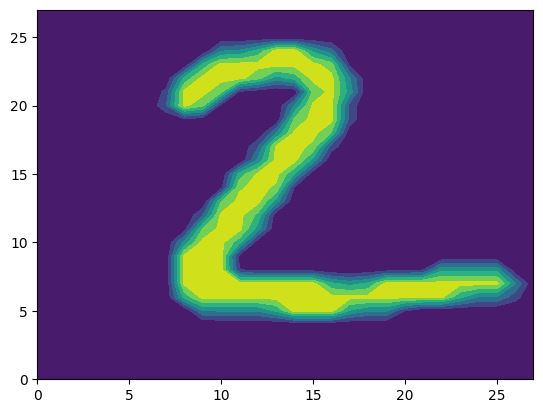

1 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254  63   

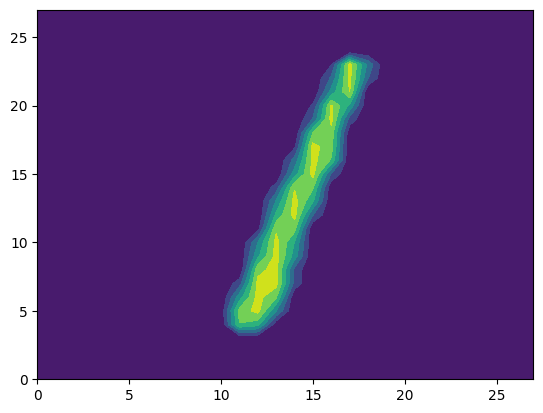

0 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251 251 253 251 251 22

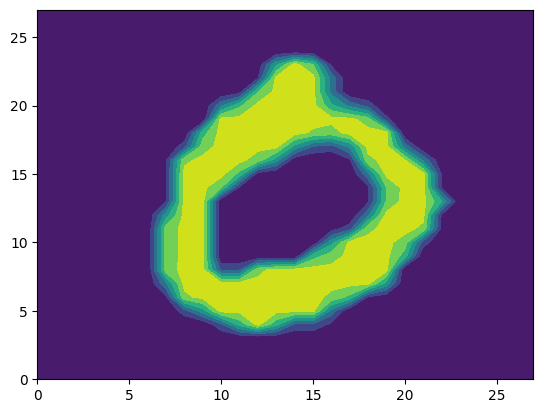

4 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0   0   0   0   0   

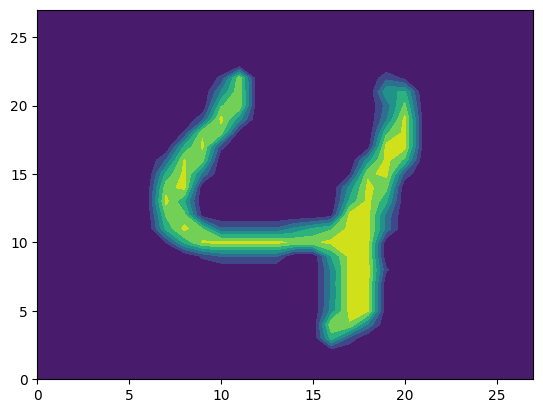

In [19]:
# Visualize the data
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()

In [ ]:
# 2 -- Shapes of the datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# for i in range(len(X_train)):
#     print("Shape of X_train[{}]: {}".format(i, X_train[i].shape))

# for i in range(len(X_test)):
#     print("Shape of X_test[{}]: {}".format(i, X_test[i].shape))


print("For each index 'i', it is the same shape of (28,28) ")
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (60000, 28, 28)
Shape of X_test: (10000, 28, 28)
Shape of X_train[0]: (28, 28)
Shape of X_train[1]: (28, 28)
Shape of X_train[2]: (28, 28)
Shape of X_train[3]: (28, 28)
Shape of X_train[4]: (28, 28)
Shape of X_train[5]: (28, 28)
Shape of X_train[6]: (28, 28)
Shape of X_train[7]: (28, 28)
Shape of X_train[8]: (28, 28)
Shape of X_train[9]: (28, 28)
Shape of X_train[10]: (28, 28)
Shape of X_train[11]: (28, 28)
Shape of X_train[12]: (28, 28)
Shape of X_train[13]: (28, 28)
Shape of X_train[14]: (28, 28)
Shape of X_train[15]: (28, 28)
Shape of X_train[16]: (28, 28)
Shape of X_train[17]: (28, 28)
Shape of X_train[18]: (28, 28)
Shape of X_train[19]: (28, 28)
Shape of X_train[20]: (28, 28)
Shape of X_train[21]: (28, 28)
Shape of X_train[22]: (28, 28)
Shape of X_train[23]: (28, 28)
Shape of X_train[24]: (28, 28)
Shape of X_train[25]: (28, 28)
Shape of X_train[26]: (28, 28)
Shape of X_train[27]: (28, 28)
Shape of X_train[28]: (28, 28)
Shape of X_train[29]: (28, 28)
Shape of X_tr

In [6]:
# 3 -- Reshape the datasets

reshaped_train = []
for x in X_train:
    reshaped_train.append(x.reshape((1, 784)))

X_train_reshaped = np.array(reshaped_train).reshape(len(X_train), 784)

reshaped_test = []
for x in X_test:
    reshaped_test.append(x.reshape((1, 784)))
X_test_reshaped = np.array(reshaped_test).reshape(len(X_test), 784)

print("Reshaped X_train:", X_train_reshaped.shape)
print("Reshaped X_test:", X_test_reshaped.shape)

Reshaped X_train: (60000, 784)
Reshaped X_test: (10000, 784)


In [9]:
# 4 -- Create k-nearest neighbor classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

k_values = range(1,11)
best_k = None
best_accuracy = 0
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_reshaped, y_train)
    y_pred = knn.predict(X_test_reshaped)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for k={k}: {accuracy}")
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

Accuracy for k=1: 0.9691
Accuracy for k=2: 0.9627
Accuracy for k=3: 0.9705
Accuracy for k=4: 0.9682
Accuracy for k=5: 0.9688
Accuracy for k=6: 0.9677
Accuracy for k=7: 0.9694
Accuracy for k=8: 0.967
Accuracy for k=9: 0.9659
Accuracy for k=10: 0.9665


In [10]:
# 5 -- Report Findings
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_reshaped, y_train)
y_pred = knn.predict(X_test_reshaped)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

print("Based on the results, we see that the KNN is quite accurate in classifying the digits, with an accuracy of 97.05%")
print("We are also testing on k=3 for the best k value")

Accuracy: 0.9705
Confusion Matrix:
 [[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  10    9  996    2    0    0    0   13    2    0]
 [   0    2    4  976    1   13    1    7    3    3]
 [   1    6    0    0  950    0    4    2    0   19]
 [   6    1    0   11    2  859    5    1    3    4]
 [   5    3    0    0    3    3  944    0    0    0]
 [   0   21    5    0    1    0    0  991    0   10]
 [   8    2    4   16    8   11    3    4  914    4]
 [   4    5    2    8    9    2    1    8    2  968]]
Based on the results, we see that the KNN is quite accurate in classifying the digits, with an accuracy of 97.05%
We are also testing on k=3 for the best k value


In [17]:
# 6 -- Confusion Matrix Analysis
print("Confusion Matrix:\n", conf_matrix)

# Analyze common mistakes
mistakes = []
for i in range(len(conf_matrix)):
    for j in range(len(conf_matrix)):
        if i != j:
            mistakes.append((i, j, conf_matrix[i, j]))

mistakes = sorted(mistakes, key=lambda x: x[2], reverse=True)

for i, j, count in mistakes[:len(mistakes)]:
    print(f"True label {i} predicted as {j}: {count} times")

print("Some patterns that I see are that the labels that get mislabelled the most are the ones that look similar to each other.")
print("For example, 7 got predicted as 1... 21 times! I would say this is because the numbers look pretty similar. This is the same for like 4 and 9 and then 8 and 3. They have similar patterns/shapes to them so thats probably why")


Confusion Matrix:
 [[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  10    9  996    2    0    0    0   13    2    0]
 [   0    2    4  976    1   13    1    7    3    3]
 [   1    6    0    0  950    0    4    2    0   19]
 [   6    1    0   11    2  859    5    1    3    4]
 [   5    3    0    0    3    3  944    0    0    0]
 [   0   21    5    0    1    0    0  991    0   10]
 [   8    2    4   16    8   11    3    4  914    4]
 [   4    5    2    8    9    2    1    8    2  968]]
True label 7 predicted as 1: 21 times
True label 4 predicted as 9: 19 times
True label 8 predicted as 3: 16 times
True label 2 predicted as 7: 13 times
True label 3 predicted as 5: 13 times
True label 5 predicted as 3: 11 times
True label 8 predicted as 5: 11 times
True label 2 predicted as 0: 10 times
True label 7 predicted as 9: 10 times
True label 2 predicted as 1: 9 times
True label 9 predicted as 4: 9 times
True label 8 predicted as 0: 8 tim

#7 -- Answer

 To represent a color photo in matrix form, we could create data that takes in the form of (width, length, rgb). rgb is a number value that can be inserted. For example, something like a 256x256 photo could be translated into a thing of like (256, 256, 5) etc. You can then turn this into a variable/number by flattening the 3d array into 2D so that each row represents a pixel. This can be used to flatten into a tabular form and then use that to do data analysis.